/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.6937, D acc: 50.00%] [Real acc: 100.00%, Fake acc: 0.00%, Overall GAN acc: 50.00%] [G loss: 0.6920]
200 [D loss: 0.6944, D acc: 45.69%] [Real acc: 100.00%, Fake acc: 0.00%, Overall GAN acc: 50.00%] [G loss: 0.6893]
400 [D loss: 0.6946, D acc: 44.87%] [Real acc: 100.00%, Fake acc: 0.00%, Overall GAN acc: 50.00%] [G loss: 0.6892]
600 [D loss: 0.6946, D acc: 44.42%] [Real acc: 100.00%, Fake acc: 0.00%, Overall GAN acc: 50.00%] [G loss: 0.6891]
800 [D loss: 0.6946, D acc: 44.10%] [Real acc: 100.00%, Fake acc: 0.00%, Overall GAN acc: 50.00%] [G loss: 0.6891]


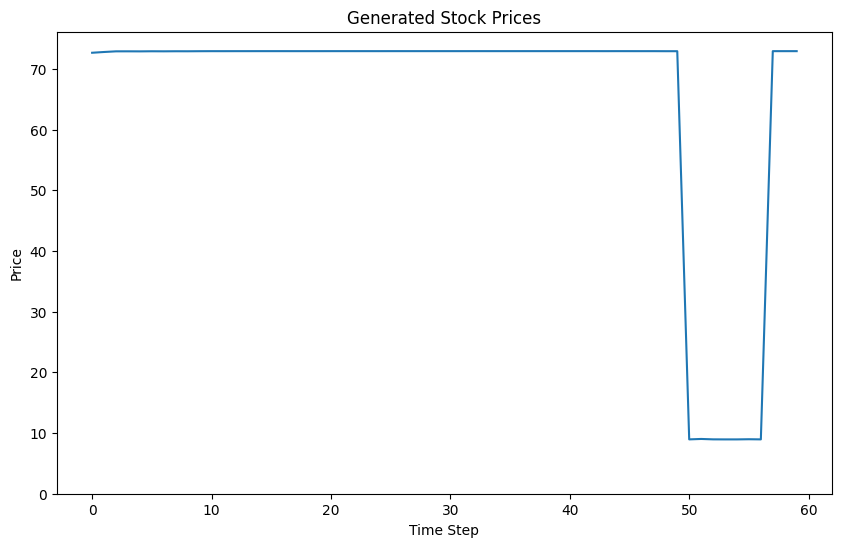

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, LeakyReLU, Dropout, Reshape, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

df = pd.read_csv('/content/drive/MyDrive/stock_data.csv')
prices = df['Close'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(prices)

def prepare_data(data, time_steps=60):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, 0])
    X = np.array(X)
    return X.reshape((X.shape[0], X.shape[1], 1))

time_step = 60
X_train = prepare_data(scaled_data, time_step)

generator = Sequential([
    LSTM(128, input_shape=(100,1), return_sequences=True),
    LeakyReLU(alpha=0.2),
    BatchNormalization(momentum=0.8),
    LSTM(64, return_sequences=True),
    LeakyReLU(alpha=0.2),
    BatchNormalization(momentum=0.8),
    Flatten(),
    Dense(time_step, activation='sigmoid'),
    Reshape((time_step,1))
])

discriminator = Sequential([
    LSTM(128, input_shape=(time_step,1), return_sequences=True),
    LeakyReLU(alpha=0.2),
    Dropout(0.3),
    LSTM(64),
    LeakyReLU(alpha=0.2),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

discriminator.compile(loss='binary_crossentropy', optimizer=Adam(0.0002,0.5), metrics=['accuracy'])

discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(loss='binary_crossentropy', optimizer=Adam(0.0002,0.5))

def train_gan(X_train, epochs=1000, batch_size=32, save_interval=200):
    half_batch = batch_size // 2
    for epoch in range(epochs):
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_data = X_train[idx]
        noise = np.random.normal(0,1,(half_batch,100,1))
        fake_data = generator.predict(noise, verbose=0)
        d_loss_real = discriminator.train_on_batch(real_data, np.ones((half_batch,1)))
        d_loss_fake = discriminator.train_on_batch(fake_data, np.zeros((half_batch,1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
        noise = np.random.normal(0,1,(batch_size,100,1))
        valid_y = np.ones((batch_size,1))
        g_loss = gan.train_on_batch(noise, valid_y)
        if epoch % save_interval == 0:
            pred_real = discriminator.predict(real_data, verbose=0)
            pred_fake = discriminator.predict(fake_data, verbose=0)
            pred_real_class = (pred_real >= 0.5).astype(int)
            pred_fake_class = (pred_fake >= 0.5).astype(int)
            acc_real = np.mean(pred_real_class == 1)
            acc_fake = np.mean(pred_fake_class == 0)
            overall_acc = 0.5 * (acc_real + acc_fake)
            print(f"{epoch} [D loss: {d_loss[0]:.4f}, D acc: {100*d_loss[1]:.2f}%] "
                  f"[Real acc: {acc_real*100:.2f}%, Fake acc: {acc_fake*100:.2f}%, Overall GAN acc: {overall_acc*100:.2f}%] "
                  f"[G loss: {g_loss:.4f}]")

train_gan(X_train, epochs=1000, batch_size=32, save_interval=200)

noise = np.random.normal(0,1,(1,100,1))
generated_stock_prices = generator.predict(noise, verbose=0)
generated_stock_prices = scaler.inverse_transform(generated_stock_prices.reshape(-1,1))

plt.figure(figsize=(10,6))
plt.plot(range(len(generated_stock_prices)), generated_stock_prices)
plt.title("Generated Stock Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.ylim(bottom=0)
plt.show()


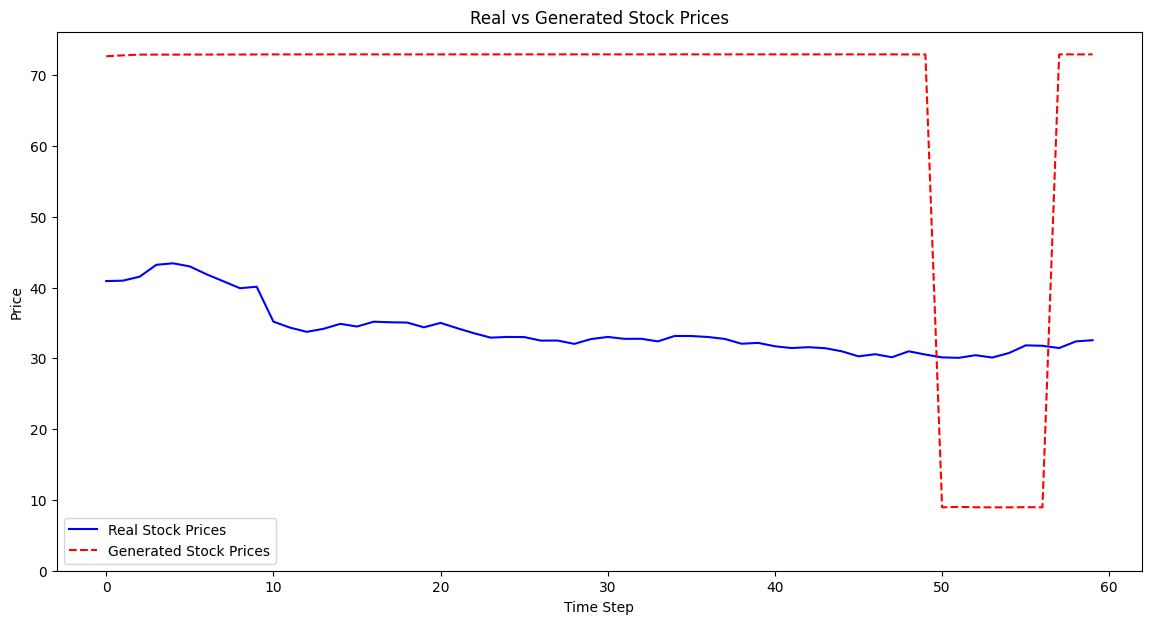

In [179]:
real_stock_prices=scaler.inverse_transform(X_train[0].reshape(-1,1))
# Plotting the real stock prices
plt.figure(figsize=(14,7))
plt.plot(real_stock_prices,color='blue',label='Real Stock Prices')
plt.plot(generated_stock_prices,color='red',linestyle='--',label='Generated Stock Prices')
plt.title('Real vs Generated Stock Prices')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.ylim(bottom=0)
plt.legend()
plt.show()

In [180]:
mse=mean_squared_error(real_stock_prices,generated_stock_prices)

In [ ]:
!git config --global user.email "tarunveer7156@gmail.com"
!git config --global user.name "TarunSingh7156"


In [ ]:
!git clone https://github.com/TarunSingh7156/AI-Stock-Market-Trend-Prediction.git


Cloning into 'AI-Stock-Market-Trend-Prediction'...


In [ ]:
!mv /content/Stock_Market_Project.ipynb /content/AI-Stock-Market-Trend-Prediction/


mv: cannot stat '/content/Stock_Market_Project.ipynb': No such file or directory


In [ ]:
%cd /content/AI-Stock-Market-Trend-Prediction
!git add .
!git commit -m "Initial commit - AI Stock Market Trend Prediction Project"
!git remote set-url origin https://github.com/TarunSingh7156/AI-Stock-Market-Trend-Prediction
!git push origin main


/content/AI-Stock-Market-Trend-Prediction
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/TarunSingh7156/AI-Stock-Market-Trend-Prediction'
